# K-Means Clustering on All Human Cash-Game Texas Hold'em Data

This notebook loads the fully preprocessed human cash-game Texas Hold'em player dataset and runs the clustering workflow described in the project reports.

## Why this notebook exists
- Apply a data-driven clustering approach to the full selected Hold'em scope
- Compare clustering quality against the heuristic TAG/LAG/Fish/Rock baseline
- Document the model-selection and interpretation steps clearly for the report and demo


In [1]:
from __future__ import annotations

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import drive

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/My Drive/CS 4824 Group Project/'
PROCESSED_DIR = PROJECT_ROOT + 'data/processed'
INTERMEDIATE_DIR = PROJECT_ROOT + 'data/intermediate'
FIGURES_DIR = PROJECT_ROOT + 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

PLAYER_STATS_PATH = PROCESSED_DIR + '/player_stats_all_human_holdem.csv'
CLUSTERED_OUTPUT_PATH = PROCESSED_DIR + '/player_clusters_all_human_holdem.csv'
CENTROIDS_PATH = PROCESSED_DIR + '/player_cluster_centroids_all_human_holdem.csv'
MODEL_SELECTION_PATH = INTERMEDIATE_DIR + '/kmeans_model_selection_all_human_holdem.csv'
ELBOW_SILHOUETTE_FIG_PATH = FIGURES_DIR + '/holdem_kmeans_model_selection.png'
CLUSTER_SCATTER_FIG_PATH = FIGURES_DIR + '/holdem_kmeans_cluster_scatter.png'
SILHOUETTE_FIG_PATH = FIGURES_DIR + '/holdem_kmeans_silhouette_plot.png'

RANDOM_STATE = 42
K_RANGE = range(2, 9)
FINAL_K = 4

Mounted at /content/drive


## Load the Processed Player Table

This file is produced by the preprocessing notebook and already contains the core player-level features used throughout the reports.

In [3]:
player_stats = pd.read_csv(PLAYER_STATS_PATH)
print(f'Loaded {len(player_stats):,} players from: {PLAYER_STATS_PATH}')
display(player_stats.head())

Loaded 16,439 players from: /content/drive/My Drive/CS 4824 Group Project/data/processed/player_stats_all_human_holdem.csv


,player,total_hands,vpip_hands,pfr_hands,channels_played_count,months_played_count,channels_played,VPIP,PFR,heuristic_label,vpip_minus_pfr
0,r00lbot,280960,39561,17185,2,23,"holdem,holdem1",14.080652,6.116529,Rock,7.964123
1,kfish,258148,67594,21722,3,48,"holdem,holdem1,holdemii",26.184204,8.414553,Fish,17.769652
2,kwAAkbot,194651,45736,12424,2,19,"holdem,holdem1",23.496412,6.382705,Rock,17.113706
3,loki,101821,31311,12498,3,11,"holdem,holdem1,holdemii",30.751024,12.274482,Fish,18.476542
4,Funky,83715,44765,661,2,29,"holdem,holdem1",53.473093,0.789584,Fish,52.683510


## Sanity Checks on the Clustering Input

Before clustering, we confirm that the expected columns are present and that the feature values look valid.

In [4]:
required_columns = ['player', 'total_hands', 'VPIP', 'PFR', 'heuristic_label']
missing_columns = [col for col in required_columns if col not in player_stats.columns]
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')

duplicate_players = int(player_stats['player'].duplicated().sum())
missing_summary = player_stats[required_columns].isna().sum().rename('missing_values')
pfr_gt_vpip_violations = int((player_stats['PFR'] > player_stats['VPIP']).sum())

print(f'Duplicate player rows: {duplicate_players}')
print(f'PFR > VPIP violations: {pfr_gt_vpip_violations}')
display(missing_summary.to_frame().T)
display(player_stats[['total_hands', 'VPIP', 'PFR']].describe().round(2))

Duplicate player rows: 0
PFR > VPIP violations: 0


,player,total_hands,VPIP,PFR,heuristic_label
missing_values,1,0,0,0,0


,total_hands,VPIP,PFR
count,16439.00,16439.00,16439.00
mean,1185.77,51.08,15.01
std,4742.66,19.14,16.64
min,30.00,0.00,0.00
25%,81.00,36.55,5.00
50%,225.00,48.84,9.90
75%,822.00,64.15,18.15
max,280960.00,100.00,100.00


These checks make sure we are clustering the same cleaned feature table that we intended to build in the preprocessing stage.

## Visual Preview of the Input Feature Space

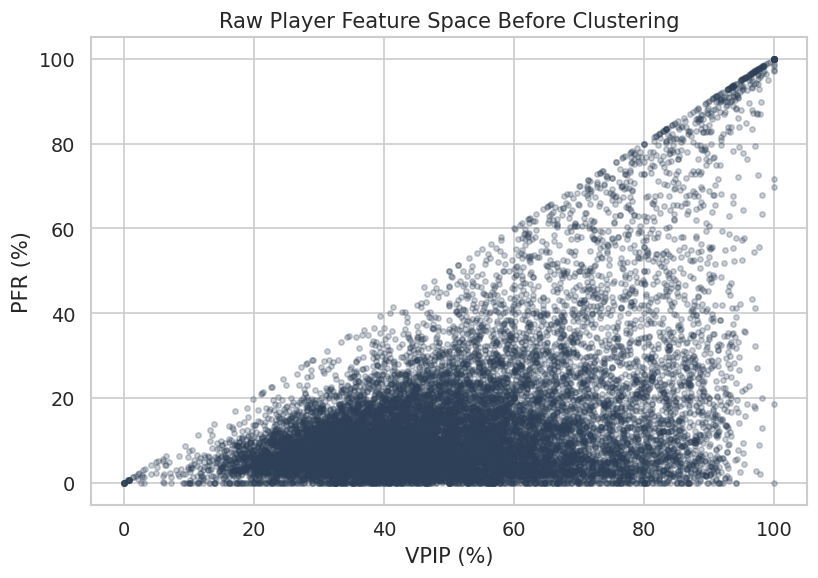

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(player_stats['VPIP'], player_stats['PFR'], s=10, alpha=0.25, color='#2e4057')
ax.set_title('Raw Player Feature Space Before Clustering')
ax.set_xlabel('VPIP (%)')
ax.set_ylabel('PFR (%)')
plt.tight_layout()
plt.show()

This scatter plot gives us a qualitative sense of whether there appear to be broad groupings before K-Means is applied.

## Standardize the Features

K-Means uses Euclidean distance, so we standardize `VPIP` and `PFR` to put them on comparable scales.

In [6]:
feature_columns = ['VPIP', 'PFR']
X = player_stats[feature_columns].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_preview = pd.DataFrame(X_scaled, columns=['VPIP_scaled', 'PFR_scaled'])
display(scaled_preview.head())
display(scaled_preview.describe().round(3))

,VPIP_scaled,PFR_scaled
0,-1.932659,-0.534355
1,-1.300427,-0.396210
2,-1.440825,-0.518354
3,-1.061879,-0.164170
4,0.125014,-0.854584


,VPIP_scaled,PFR_scaled
count,16439.000,16439.000
mean,-0.000,0.000
std,1.000,1.000
min,-2.668,-0.902
25%,-0.759,-0.601
50%,-0.117,-0.307
75%,0.683,0.189
max,2.555,5.109


## Evaluate Multiple Values of `K`

We compare `K=2..8` using both inertia and silhouette score. This lets us discuss both model fit and cluster separation in the final report.

In [7]:
selection_rows = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)

    selection_rows.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette_score': sil,
    })

model_selection = pd.DataFrame(selection_rows)
model_selection.to_csv(MODEL_SELECTION_PATH, index=False)

best_k = int(model_selection.loc[model_selection['silhouette_score'].idxmax(), 'k'])
best_silhouette = float(model_selection['silhouette_score'].max())

print(f'Best K by silhouette: {best_k}')
print(f'Best silhouette score: {best_silhouette:.4f}')
display(model_selection.round(4))

Best K by silhouette: 2
Best silhouette score: 0.4917


,k,inertia,silhouette_score
0,2,18086.2318,0.4917
1,3,10067.7645,0.4516
2,4,7730.9422,0.4420
3,5,5781.4775,0.3816
4,6,4775.3330,0.3909
5,7,4038.9806,0.3588
6,8,3518.0271,0.3602


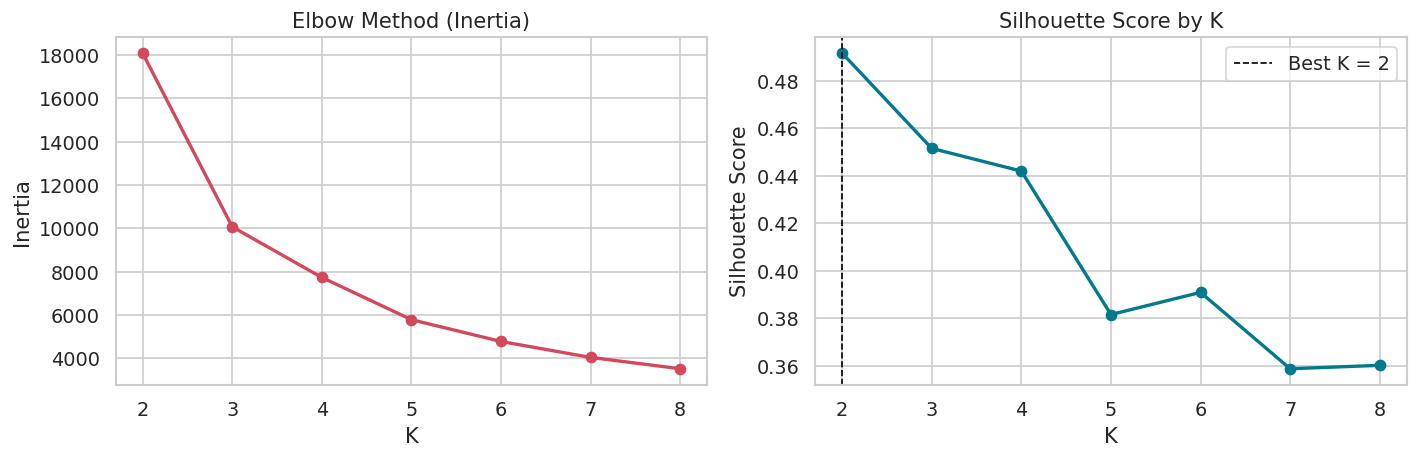

Saved model-selection figure to: /content/drive/My Drive/CS 4824 Group Project/figures/holdem_kmeans_model_selection.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(model_selection['k'], model_selection['inertia'], 'o-', color='#d1495b', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(model_selection['k'], model_selection['silhouette_score'], 'o-', color='#00798c', linewidth=2)
axes[1].axvline(best_k, linestyle='--', color='black', linewidth=1, label=f'Best K = {best_k}')
axes[1].set_title('Silhouette Score by K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()

plt.tight_layout()
plt.savefig(ELBOW_SILHOUETTE_FIG_PATH, bbox_inches='tight')
plt.show()

print(f'Saved model-selection figure to: {ELBOW_SILHOUETTE_FIG_PATH}')

This stage gives us the evidence for discussing whether four clusters is mainly a theory-driven choice, a data-driven choice, or a compromise between both.

## Fit the Final K-Means Model

For consistency with the report framing and the four traditional poker archetypes, we fit the final comparison model with `K = 4`.

In [9]:
km_final = KMeans(n_clusters=FINAL_K, n_init=20, random_state=RANDOM_STATE)
player_stats['cluster'] = km_final.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, player_stats['cluster'])
print(f'Final K-Means silhouette score (K={FINAL_K}): {final_silhouette:.4f}')
display(player_stats[['player', 'VPIP', 'PFR', 'heuristic_label', 'cluster']].head())

Final K-Means silhouette score (K=4): 0.4420


,player,VPIP,PFR,heuristic_label,cluster
0,r00lbot,14.080652,6.116529,Rock,0
1,kfish,26.184204,8.414553,Fish,0
2,kwAAkbot,23.496412,6.382705,Rock,0
3,loki,30.751024,12.274482,Fish,0
4,Funky,53.473093,0.789584,Fish,2


## Inspect Cluster Centroids and Sizes

We transform centroids back to the original VPIP/PFR scale so the cluster profiles can be interpreted in poker terms.

In [10]:
centroids_original = scaler.inverse_transform(km_final.cluster_centers_)
cluster_sizes = player_stats['cluster'].value_counts().sort_index()

centroid_df = pd.DataFrame(centroids_original, columns=['VPIP_centroid', 'PFR_centroid'])
centroid_df['cluster'] = centroid_df.index
centroid_df['cluster_size'] = centroid_df['cluster'].map(cluster_sizes)
centroid_df['vpip_minus_pfr'] = centroid_df['VPIP_centroid'] - centroid_df['PFR_centroid']
centroid_df = centroid_df[['cluster', 'cluster_size', 'VPIP_centroid', 'PFR_centroid', 'vpip_minus_pfr']]
centroid_df = centroid_df.sort_values('cluster').reset_index(drop=True)
centroid_df.to_csv(CENTROIDS_PATH, index=False)
display(centroid_df.round(2))

,cluster,cluster_size,VPIP_centroid,PFR_centroid,vpip_minus_pfr
0,0,8542,36.11,8.88,27.23
1,1,722,84.39,74.86,9.53
2,2,4838,65.65,8.74,56.91
3,3,2337,65.59,32.00,33.59


In [11]:
heuristic_by_cluster = pd.crosstab(player_stats['cluster'], player_stats['heuristic_label'])
display(heuristic_by_cluster)

heuristic_label,Fish,LAG,Rock,TAG
cluster,,,,
0,6150,1318,1042,32
1,0,722,0,0
2,3990,848,0,0
3,0,2337,0,0


The centroid table and cluster-by-heuristic table together make it easier to explain whether the unsupervised clusters resemble TAG, LAG, Fish, and Rock or reveal a different structure.

## Visualize the Cluster Assignments

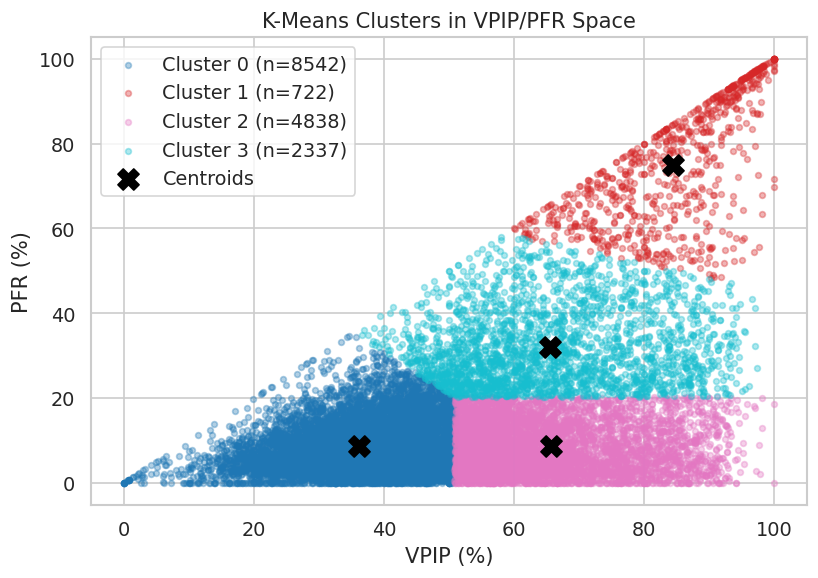

Saved cluster-scatter figure to: /content/drive/My Drive/CS 4824 Group Project/figures/holdem_kmeans_cluster_scatter.png


In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
cmap = plt.get_cmap('tab10', FINAL_K)

for cluster_id in range(FINAL_K):
    mask = player_stats['cluster'] == cluster_id
    ax.scatter(
        player_stats.loc[mask, 'VPIP'],
        player_stats.loc[mask, 'PFR'],
        s=12,
        alpha=0.35,
        label=f'Cluster {cluster_id} (n={mask.sum()})',
        color=cmap(cluster_id),
    )

ax.scatter(
    centroid_df['VPIP_centroid'],
    centroid_df['PFR_centroid'],
    marker='X',
    s=160,
    c='black',
    label='Centroids',
)

ax.set_title('K-Means Clusters in VPIP/PFR Space')
ax.set_xlabel('VPIP (%)')
ax.set_ylabel('PFR (%)')
ax.legend()
plt.tight_layout()
plt.savefig(CLUSTER_SCATTER_FIG_PATH, bbox_inches='tight')
plt.show()

print(f'Saved cluster-scatter figure to: {CLUSTER_SCATTER_FIG_PATH}')

## Silhouette Plot

This plot shows how well each player fits within its assigned cluster under the final `K = 4` model.

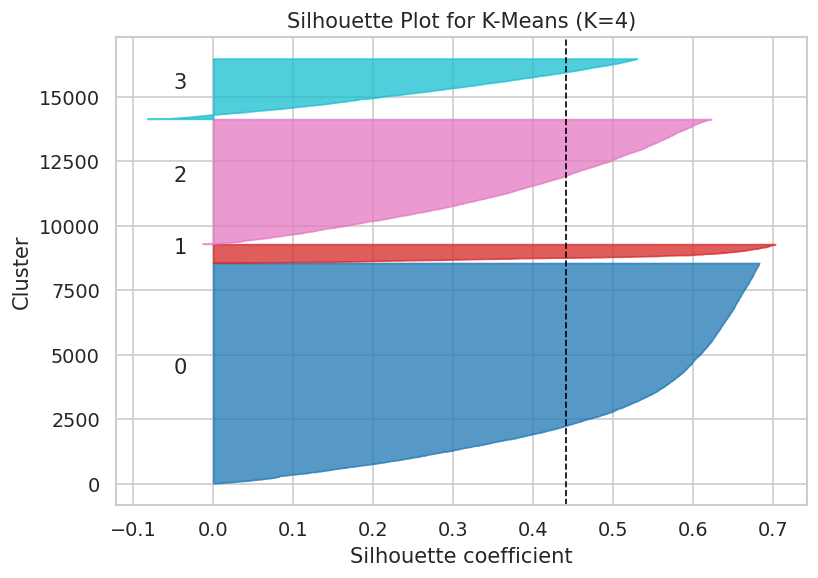

Saved silhouette figure to: /content/drive/My Drive/CS 4824 Group Project/figures/holdem_kmeans_silhouette_plot.png


In [13]:
silhouette_values = silhouette_samples(X_scaled, player_stats['cluster'])
y_lower = 10

fig, ax = plt.subplots(figsize=(7, 5))

for cluster_id in range(FINAL_K):
    cluster_silhouette = np.sort(silhouette_values[player_stats['cluster'] == cluster_id])
    y_upper = y_lower + len(cluster_silhouette)

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette,
        facecolor=cmap(cluster_id),
        edgecolor=cmap(cluster_id),
        alpha=0.75,
    )
    ax.text(-0.05, y_lower + 0.5 * len(cluster_silhouette), str(cluster_id))
    y_lower = y_upper + 10

ax.axvline(final_silhouette, color='black', linestyle='--', linewidth=1)
ax.set_title(f'Silhouette Plot for K-Means (K={FINAL_K})')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig(SILHOUETTE_FIG_PATH, bbox_inches='tight')
plt.show()

print(f'Saved silhouette figure to: {SILHOUETTE_FIG_PATH}')

## Compare Against the Heuristic Baseline

We compare the silhouette score of the heuristic labels with both the final `K=4` K-Means model and the best silhouette-performing K-Means choice across the tested range.

In [14]:
label_map = {'TAG': 0, 'LAG': 1, 'Fish': 2, 'Rock': 3}
heuristic_silhouette = silhouette_score(X_scaled, player_stats['heuristic_label'].map(label_map))

comparison_df = pd.DataFrame([
    {'method': 'Heuristic baseline', 'k_or_groups': 4, 'silhouette_score': heuristic_silhouette},
    {'method': f'K-Means (K={FINAL_K})', 'k_or_groups': FINAL_K, 'silhouette_score': final_silhouette},
    {'method': f'Best K-Means by silhouette (K={best_k})', 'k_or_groups': best_k, 'silhouette_score': best_silhouette},
])

display(comparison_df.round(4))

if final_silhouette > heuristic_silhouette:
    print('K-Means with K=4 outperforms the heuristic baseline on silhouette score.')
else:
    print('The heuristic baseline is competitive with or better than K-Means with K=4 on silhouette score.')

,method,k_or_groups,silhouette_score
0,Heuristic baseline,4,0.1347
1,K-Means (K=4),4,0.4420
2,Best K-Means by silhouette (K=2),2,0.4917


K-Means with K=4 outperforms the heuristic baseline on silhouette score.


This comparison is the main quantitative result for the project because it tells us whether the data-driven grouping is more coherent than the rule-based baseline.

## Save Final Outputs

In [15]:
player_stats.to_csv(CLUSTERED_OUTPUT_PATH, index=False)

print(f'Clustered player output saved to: {CLUSTERED_OUTPUT_PATH}')
print(f'Cluster centroid summary saved to: {CENTROIDS_PATH}')
print(f'Model selection summary saved to: {MODEL_SELECTION_PATH}')
display(player_stats.head())

Clustered player output saved to: /content/drive/My Drive/CS 4824 Group Project/data/processed/player_clusters_all_human_holdem.csv
Cluster centroid summary saved to: /content/drive/My Drive/CS 4824 Group Project/data/processed/player_cluster_centroids_all_human_holdem.csv
Model selection summary saved to: /content/drive/My Drive/CS 4824 Group Project/data/intermediate/kmeans_model_selection_all_human_holdem.csv


,player,total_hands,vpip_hands,pfr_hands,channels_played_count,months_played_count,channels_played,VPIP,PFR,heuristic_label,vpip_minus_pfr,cluster
0,r00lbot,280960,39561,17185,2,23,"holdem,holdem1",14.080652,6.116529,Rock,7.964123,0
1,kfish,258148,67594,21722,3,48,"holdem,holdem1,holdemii",26.184204,8.414553,Fish,17.769652,0
2,kwAAkbot,194651,45736,12424,2,19,"holdem,holdem1",23.496412,6.382705,Rock,17.113706,0
3,loki,101821,31311,12498,3,11,"holdem,holdem1,holdemii",30.751024,12.274482,Fish,18.476542,0
4,Funky,83715,44765,661,2,29,"holdem,holdem1",53.473093,0.789584,Fish,52.683510,2


## Key Takeaways

- We verified the clustering input and standardized the final full-dataset Hold'em features.
- We evaluated multiple values of `K` and recorded both inertia and silhouette score.
- We fit the final `K = 4` model to align with the four traditional player archetypes.
- We interpreted the clusters through centroids, cluster sizes, and heuristic-label overlap.
- We compared K-Means directly against the heuristic baseline and saved all outputs needed for the report and presentation.
